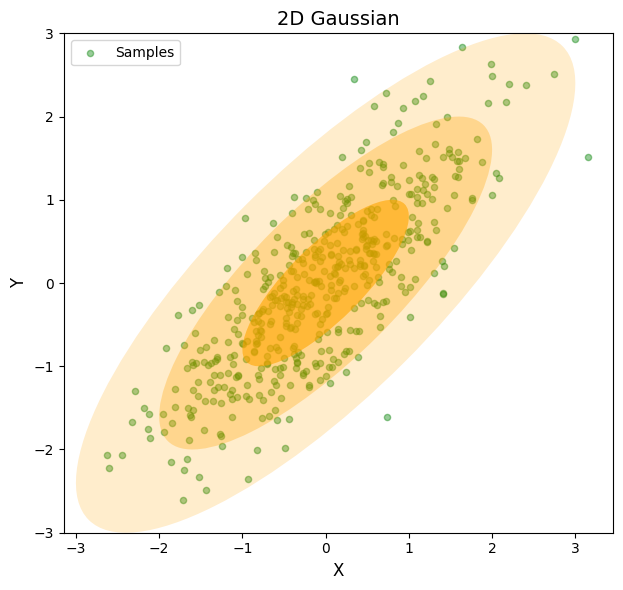

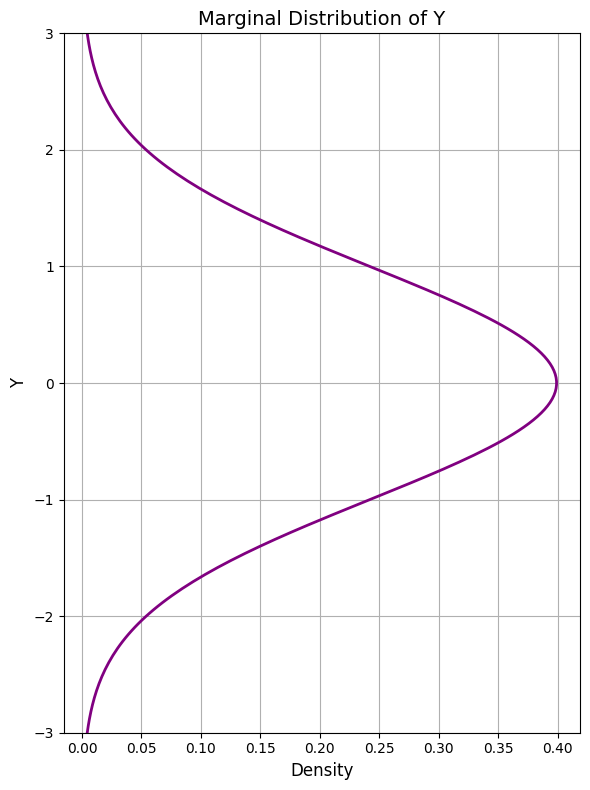

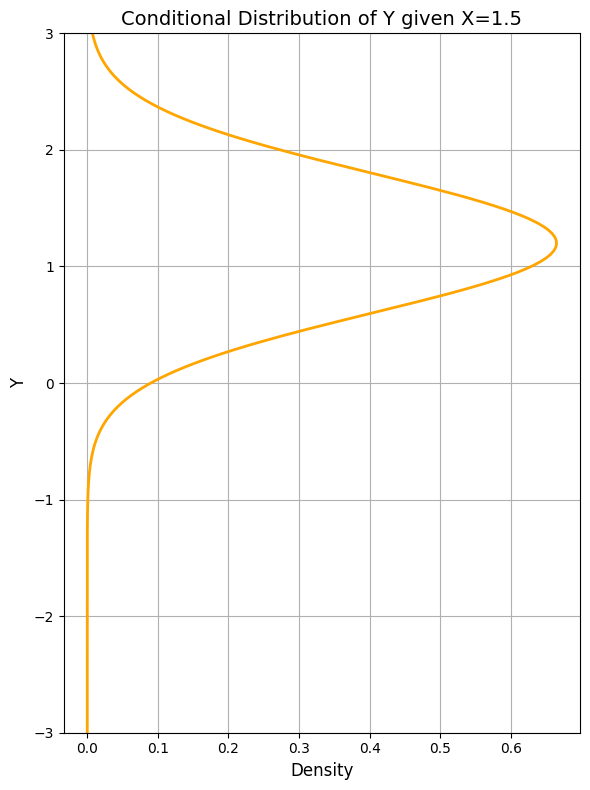

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, norm
from matplotlib.patches import Ellipse

# Color palette:
# Purple: #800080
# Orange: #FFA500
# Green:  #008000
color_samples = '#008000'  # For samples
color_ellipse = '#FFA500'  # For ellipses

# Define the parameters of the 2D Gaussian
mean = [0, 0]
cov = [[1.0, 0.8],
       [0.8, 1.0]]  # positively correlated

# Generate a random sample
num_samples = 500
samples = np.random.multivariate_normal(mean, cov, num_samples)

# Compute eigenvalues and eigenvectors of the covariance
eigvals, eigvecs = np.linalg.eigh(cov)
angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))

# Standard deviation levels for ellipses (1, 2, 3)
std_levels = [1, 2, 3]

# Common Y limits
y_min, y_max = -3, 3

# -------------------------
# Figure 1: 2D Gaussian with Samples and Transparent Ellipses
# -------------------------
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(samples[:, 0], samples[:, 1], s=20, alpha=0.4, color=color_samples, label='Samples')

for i, k in enumerate(std_levels):
    width, height = 2 * k * np.sqrt(eigvals)
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle,
                      edgecolor='none', facecolor=color_ellipse, alpha=0.6/(i+1))
    ax.add_patch(ellipse)

ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_title('2D Gaussian', fontsize=14)
ax.set_aspect('equal', 'box')
ax.legend()
ax.set_ylim(y_min, y_max)  # Apply Y limits
plt.tight_layout()
plt.show()

# -------------------------
# Figure 2: Marginal Distribution of Y
# -------------------------
mean_y = 0
var_y = cov[1][1]  # This is 1.0
std_y = np.sqrt(var_y)

y_vals = np.linspace(-3, 3, 200)
pdf_marginal_y = norm.pdf(y_vals, mean_y, std_y)

fig2, ax2 = plt.subplots(figsize=(6, 8))
ax2.plot(pdf_marginal_y, y_vals, color='#800080', linewidth=2) # Purple for marginal
ax2.set_xlabel('Density', fontsize=12)
ax2.set_ylabel('Y', fontsize=12)
ax2.set_title('Marginal Distribution of Y', fontsize=14)
ax2.grid(True)
ax2.set_ylim(y_min, y_max)  # Apply Y limits
plt.tight_layout()
plt.show()

# -------------------------
# Figure 3: Conditional Distribution of Y given X = 1.5
# -------------------------
x0 = 1.5
# For the given parameters:
# μ_x=0, μ_y=0, σ_x=1, σ_y=1, ρ=0.8
mean_cond = 0 + 0.8 * (x0 - 0)  # 1.2
var_cond = 1 - (0.8**2)         # 0.36
std_cond = np.sqrt(var_cond)

y_cond_vals = np.linspace(-3, 3, 200)
pdf_conditional_y = norm.pdf(y_cond_vals, mean_cond, std_cond)

fig3, ax3 = plt.subplots(figsize=(6, 8))
ax3.plot(pdf_conditional_y, y_cond_vals, color='#FFA500', linewidth=2) # Orange for conditional
ax3.set_xlabel('Density', fontsize=12)
ax3.set_ylabel('Y', fontsize=12)
ax3.set_title(f'Conditional Distribution of Y given X={x0}', fontsize=14)
ax3.grid(True)
ax3.set_ylim(y_min, y_max)  # Apply Y limits
plt.tight_layout()
plt.show()

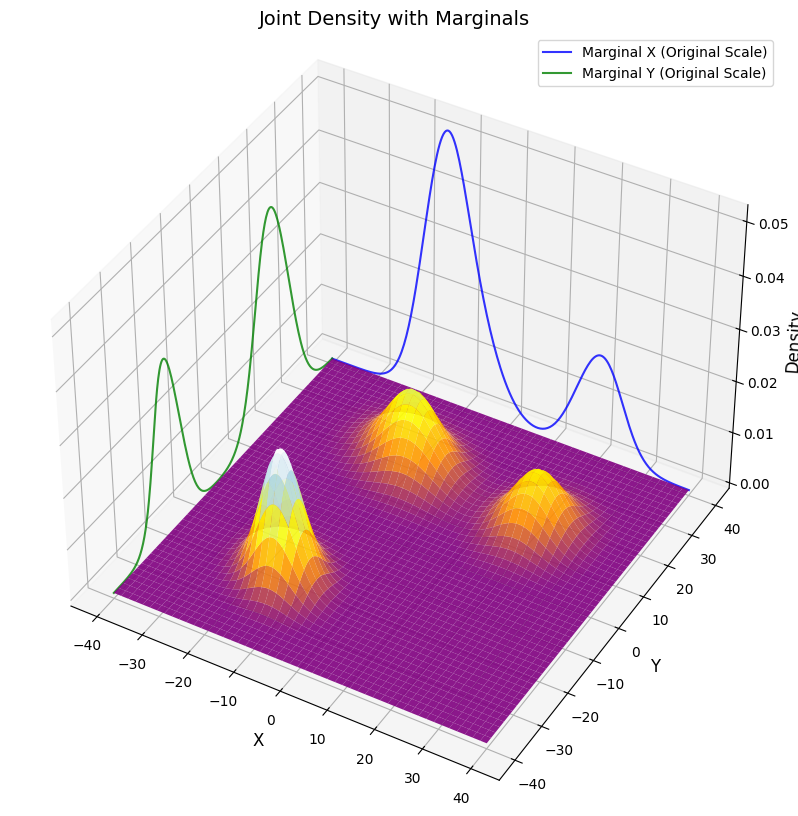

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import multivariate_normal
from matplotlib.colors import LinearSegmentedColormap

# -------------------------
# Three Gaussian Mixture Definition (Original)
# -------------------------
x = np.linspace(-40, 40, 300)
y = np.linspace(-40, 40, 300)
X, Y = np.meshgrid(x, y)

gaussian1 = multivariate_normal(mean=[-15, -20], cov=[[20, -5], [-5, 20]])
gaussian2 = multivariate_normal(mean=[20, 15], cov=[[25, 0], [0, 30]])
gaussian3 = multivariate_normal(mean=[-10, 20], cov=[[40, -10], [-10, 30]])

weights = [1.5, 1.0, 1.5]
weights_sum = sum(weights)
normalized_weights = [w / weights_sum for w in weights]

Z = (normalized_weights[0] * gaussian1.pdf(np.dstack((X, Y))) +
     normalized_weights[1] * gaussian2.pdf(np.dstack((X, Y))) +
     normalized_weights[2] * gaussian3.pdf(np.dstack((X, Y))))

# Compute Marginal Distributions (original scale)
dx = x[1] - x[0]
dy = y[1] - y[0]
marginal_x = np.sum(Z, axis=0) * dy  # Integrate over Y
marginal_y = np.sum(Z, axis=1) * dx  # Integrate over X

# Create a colormap
custom_colors = [
    "#800080",  # Purple
    "#FF8C00",  # Dark Orange
    "#FFFF00",  # Yellow
    "#ADD8E6",  # Light Blue
    "#FFFFFF"   # White
]
cmap = LinearSegmentedColormap.from_list("custom_cmap", custom_colors, N=256)

# -------------------------
# 3D Plot with Joint and Marginals
# -------------------------
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Scale the joint density by 5 before plotting
Z_scaled = Z * 8

# Plot the scaled 3D surface of the joint density
surface = ax.plot_surface(X, Y, Z_scaled, cmap=cmap, edgecolor='none', alpha=0.9)

# Plot marginals on the walls (at original scale)
# Marginal X along the top Y wall (Y = max(y))
ax.plot(x, [y[-1]] * len(x), marginal_x, color="blue", alpha=0.8, label="Marginal X (Original Scale)")

# Marginal Y along the left X wall (X = min(x))
ax.plot([x[0]] * len(y), y, marginal_y, color="green", alpha=0.8, label="Marginal Y (Original Scale)")

# Adjust viewing angle and axes
ax.view_init(elev=40, azim=-60)

# Update title and labels
ax.set_title('Joint Density with Marginals', fontsize=14)
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_zlabel('Density', fontsize=12)
ax.legend(loc='upper right')

plt.show()

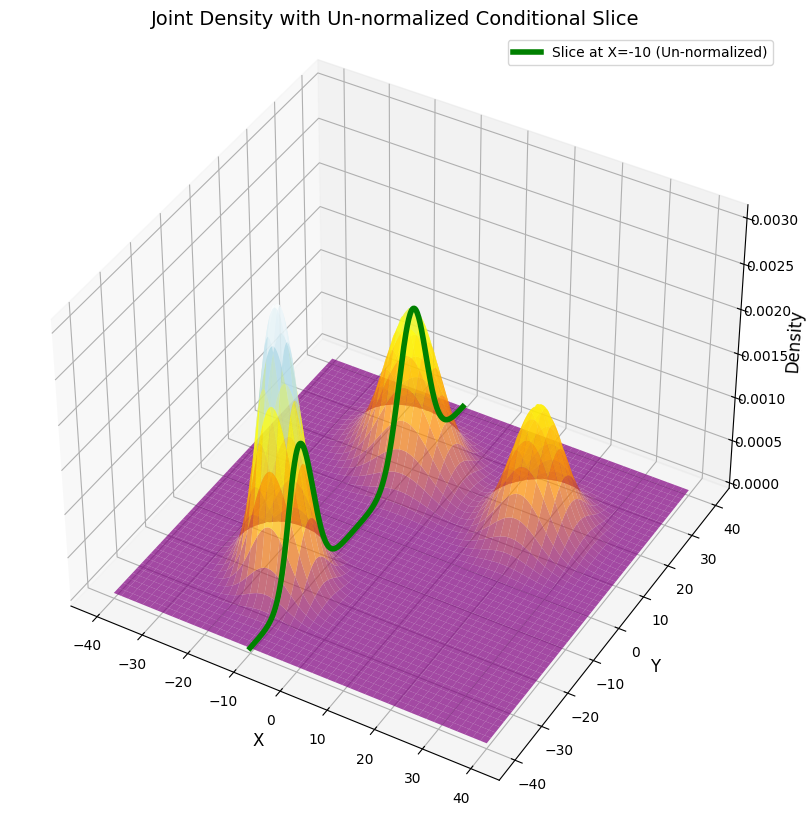

In [25]:
x0 = -10
idx_x0 = np.argmin(np.abs(x - x0))
Z_slice = Z[:, idx_x0]

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot the joint density surface without scaling
ax.plot_surface(X, Y, Z, cmap=cmap, edgecolor='none', alpha=0.7, zorder=1)

# Use green color for the conditional slice
ax.plot([x0]*len(y), y, Z_slice, color='#008000', linewidth=4, 
        label=f'Slice at X={x0} (Un-normalized)', zorder=10)

ax.set_title('Joint Density with Un-normalized Conditional Slice', fontsize=14)
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_zlabel('Density', fontsize=12)
ax.legend(loc='upper right')

# Adjust the viewing angle if needed
ax.view_init(elev=40, azim=-60)

plt.show()

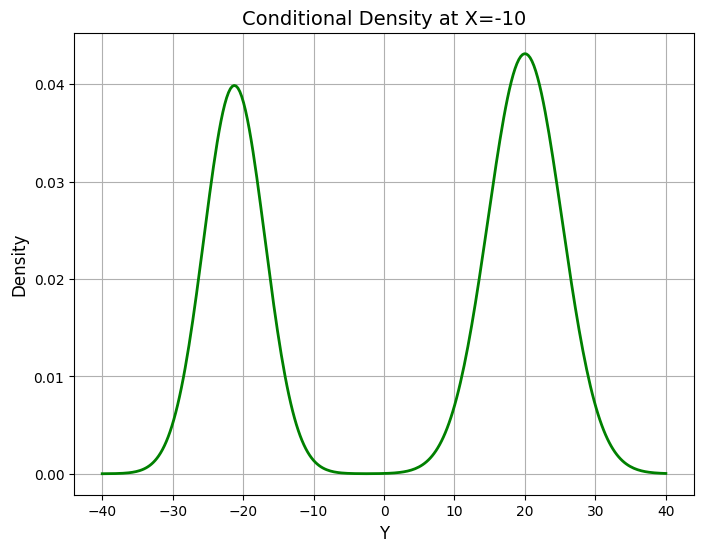

In [24]:
x0 = -10
idx_x0 = np.argmin(np.abs(x - x0))
Z_slice = Z[:, idx_x0]

# Normalize the conditional density at X = x0
Z_slice_norm = Z_slice / np.trapz(Z_slice, y)

fig, ax = plt.subplots(figsize=(8, 6))

# Plot normalized conditional density as a 2D line plot
ax.plot(y, Z_slice_norm, color='#008000', linewidth=2)  # Using green for consistency
ax.set_title(f'Conditional Density at X={x0}', fontsize=14)
ax.set_xlabel('Y', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.grid(True)

plt.show()